# 01 - Dataset Exploration

Initial inspection of the Victoria Road Crash dataset before preprocessing and model development.

In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns

print("Library Versions")
print("-" * 40)
print(f"Python         : {sys.version.split()[0]}")
print(f"Pandas         : {pd.__version__}")
print(f"NumPy          : {np.__version__}")
print(f"Scikit-learn   : {sklearn.__version__}")
print(f"Matplotlib     : {matplotlib.__version__}")
print(f"Seaborn        : {sns.__version__}")

Library Versions
----------------------------------------
Python         : 3.13.7
Pandas         : 3.0.5
NumPy          : 2.5.2
Scikit-learn   : 1.9.0
Matplotlib     : 3.11.1
Seaborn        : 0.13.2


In [2]:

DATA_PATH = "../data/victorian_road_crash_data.csv"
df = pd.read_csv(DATA_PATH)

In [ ]:
df

## First Five Records

In [3]:
df.head()

,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,DAY_OF_WEEK,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,...,NO_OF_VEHICLES,HEAVYVEHICLE,PASSENGERVEHICLE,MOTORCYCLE,PT_VEHICLE,DEG_URBAN_NAME,SRNS,RMA,DIVIDED,STAT_DIV_NAME
0,T20140024624,2014-11-27,18:35:00,Collision with vehicle,Thursday,110,CROSS TRAFFIC(INTERSECTIONS ONLY),Day,Yes,Cross intersection,...,2.0,0.0,2.0,0.0,0.0,TOWNS,NaN,Local Road,Undivided,Country
1,T20190026336,2019-12-27,15:45:00,Collision with vehicle,Friday,113,RIGHT NEAR (INTERSECTIONS ONLY),Day,Yes,T intersection,...,2.0,0.0,2.0,0.0,0.0,MELB_URBAN,NaN,Arterial Other,Divided,Metro
2,T20190019196,2019-10-02,12:07:00,Collision with vehicle,Wednesday,173,RIGHT OFF CARRIAGEWAY INTO OBJECT/PARKED VEHICLE,Day,Yes,Not at intersection,...,3.0,0.0,2.0,0.0,0.0,MELB_URBAN,M,Freeway,Divided,Metro
3,T20250029202,2025-11-07,13:10:00,Struck Pedestrian,Friday,100,PED NEAR SIDE. PED HIT BY VEHICLE FROM THE RIGHT.,Day,Yes,Not at intersection,...,1.0,0.0,1.0,0.0,0.0,MELB_URBAN,NaN,Arterial Highway,Divided,Metro
4,T20210005363,2021-01-30,06:30:00,Collision with a fixed object,Saturday,183,OFF LEFT BEND INTO OBJECT/PARKED VEHICLE,Dusk/Dawn,No,Not at intersection,...,1.0,0.0,1.0,0.0,0.0,RURAL_VICTORIA,C,Arterial Other,Undivided,Metro


## Last Ten Records

In [4]:
df.tail(10)

,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,DAY_OF_WEEK,DCA_CODE,DCA_CODE_DESCRIPTION,LIGHT_CONDITION,POLICE_ATTEND,ROAD_GEOMETRY,...,NO_OF_VEHICLES,HEAVYVEHICLE,PASSENGERVEHICLE,MOTORCYCLE,PT_VEHICLE,DEG_URBAN_NAME,SRNS,RMA,DIVIDED,STAT_DIV_NAME
200342,T20120020447,2012-08-12,14:00:00.0000000,No collision and no object struck,Sunday,174,OUT OF CONTROL ON CARRIAGEWAY (ON STRAIGHT),Day,No,Not at intersection,...,1.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN
200343,T20120029106,2012-12-30,18:05:00.0000000,Vehicle overturned (no collision),Sunday,172,OFF CARRIAGEWAY TO RIGHT,Day,Yes,Not at intersection,...,1.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
200344,T20120013446,2012-06-09,01:25:00.0000000,Collision with a fixed object,Saturday,183,OFF LEFT BEND INTO OBJECT/PARKED VEHICLE,Dark Street lights on,Yes,Not at intersection,...,1.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
200345,T20180021724,2018-11-19,10:50:00.0000000,collision with some other object,Monday,175,OFF END OF ROAD/T-INTERSECTION.,Day,Yes,Not at intersection,...,1.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
200346,T20190004398,2019-03-07,12:00:00.0000000,Collision with vehicle,Thursday,121,RIGHT THROUGH,Day,Yes,Not at intersection,...,2.0,0.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
200347,T20130004031,2013-02-23,13:00:00.0000000,Vehicle overturned (no collision),Saturday,172,OFF CARRIAGEWAY TO RIGHT,Day,Yes,Not at intersection,...,1.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
200348,T20120002126,2012-01-28,12:00:00.0000000,collision with some other object,Saturday,166,STRUCK OBJECT ON CARRIAGEWAY,Day,Yes,Not at intersection,...,1.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN
200349,T20170012528,2017-06-26,22:21:00.0000000,Collision with vehicle,Monday,137,LEFT TURN SIDESWIPE,Dark Street lights on,Yes,T intersection,...,2.0,0.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
200350,T20180010144,2018-05-28,11:56:00.0000000,Collision with vehicle,Monday,130,REAR END(VEHICLES IN SAME LANE),Day,No,Not at intersection,...,2.0,0.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
200351,T20190006335,2018-12-07,03:54:00.0000000,Collision with a fixed object,Friday,179,OTHER ACCIDENTS-OFF STRAIGHT NOT INCLUDED IN D...,Unk.,No,Unknown,...,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


## Dataset Shape

In [5]:
rows, columns = df.shape
print(f"Rows    : {rows:,}")
print(f"Columns : {columns}")

Rows    : 200,352
Columns : 52


## Column Names

In [6]:
print(list(df.columns))

['ACCIDENT_NO', 'ACCIDENT_DATE', 'ACCIDENT_TIME', 'ACCIDENT_TYPE', 'DAY_OF_WEEK', 'DCA_CODE', 'DCA_CODE_DESCRIPTION', 'LIGHT_CONDITION', 'POLICE_ATTEND', 'ROAD_GEOMETRY', 'SEVERITY', 'SPEED_ZONE', 'RUN_OFFROAD', 'ROAD_NAME', 'ROAD_TYPE', 'ROAD_ROUTE_1', 'LGA_NAME', 'DTP_REGION', 'LATITUDE', 'LONGITUDE', 'VICGRID_X', 'VICGRID_Y', 'TOTAL_PERSONS', 'INJ_OR_FATAL', 'FATALITY', 'SERIOUSINJURY', 'OTHERINJURY', 'NONINJURED', 'MALES', 'FEMALES', 'BICYCLIST', 'PASSENGER', 'DRIVER', 'PEDESTRIAN', 'PILLION', 'MOTORCYCLIST', 'UNKNOWN', 'PED_CYCLIST_5_12', 'PED_CYCLIST_13_18', 'OLD_PED_65_AND_OVER', 'OLD_DRIVER_75_AND_OVER', 'YOUNG_DRIVER_18_25', 'NO_OF_VEHICLES', 'HEAVYVEHICLE', 'PASSENGERVEHICLE', 'MOTORCYCLE', 'PT_VEHICLE', 'DEG_URBAN_NAME', 'SRNS', 'RMA', 'DIVIDED', 'STAT_DIV_NAME']


## Data Types

In [7]:
df.dtypes

ACCIDENT_NO                   str
ACCIDENT_DATE                 str
ACCIDENT_TIME                 str
ACCIDENT_TYPE                 str
DAY_OF_WEEK                   str
DCA_CODE                    int64
DCA_CODE_DESCRIPTION          str
LIGHT_CONDITION               str
POLICE_ATTEND                 str
ROAD_GEOMETRY                 str
SEVERITY                      str
SPEED_ZONE                    str
RUN_OFFROAD                   str
ROAD_NAME                     str
ROAD_TYPE                     str
ROAD_ROUTE_1              float64
LGA_NAME                      str
DTP_REGION                    str
LATITUDE                  float64
LONGITUDE                 float64
VICGRID_X                 float64
VICGRID_Y                 float64
TOTAL_PERSONS               int64
INJ_OR_FATAL                int64
FATALITY                    int64
SERIOUSINJURY               int64
OTHERINJURY                 int64
NONINJURED                  int64
MALES                       int64
FEMALES       

In [8]:
print("Data type counts:")
print(df.dtypes.value_counts())

Data type counts:
str        21
int64      21
float64    10
Name: count, dtype: int64


## Missing Values

Missing values are checked before preprocessing so that we can decide how each affected feature should be handled.

In [9]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data.sort_values("Missing Values", ascending=False)
missing_data[missing_data["Missing Values"] > 0]

,Missing Values,Percentage
SRNS,140259,70.01
RMA,7677,3.83
DIVIDED,7677,3.83
ROAD_TYPE,2740,1.37
STAT_DIV_NAME,1014,0.51
DEG_URBAN_NAME,993,0.50
ROAD_NAME,263,0.13
LGA_NAME,90,0.04
DTP_REGION,85,0.04
LONGITUDE,85,0.04


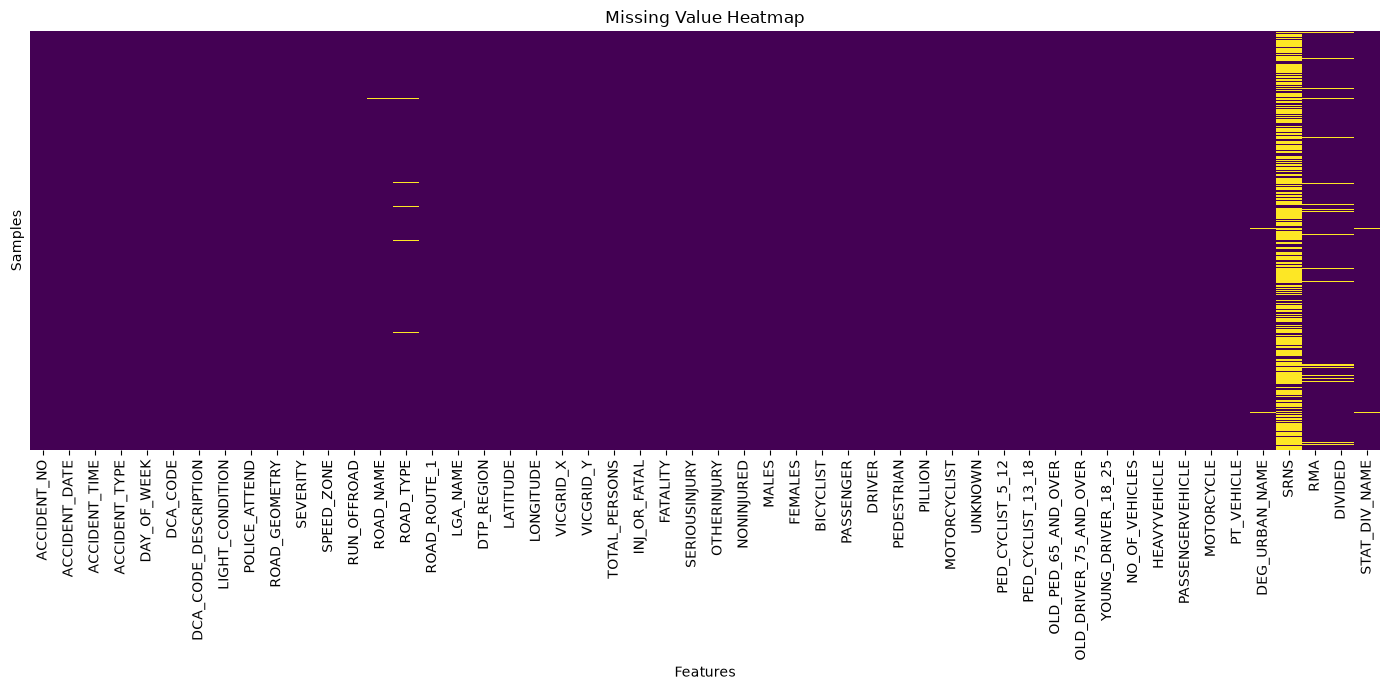

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.xlabel("Features")
plt.ylabel("Samples")
plt.tight_layout()
plt.show()

## Duplicate Records

In [11]:
duplicate_rows = df[df.duplicated()]
print(f"Total duplicate rows detected: {len(duplicate_rows):,}")
if len(duplicate_rows) > 0:
    display(duplicate_rows.head())

Total duplicate rows detected: 0


In [12]:
print(f"Duplicate row count: {df.duplicated().sum():,}")

Duplicate row count: 0


## Descriptive Statistics

Summary statistics help identify ranges, unusual values, and the general scale of numerical variables.

In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ACCIDENT_NO,200352,200352,T20140024624,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACCIDENT_DATE,200352,5114,2015-04-17,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACCIDENT_TIME,200352,1505,16:00:00,2873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACCIDENT_TYPE,200352,9,Collision with vehicle,130521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DAY_OF_WEEK,200352,7,Friday,31530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DCA_CODE,200352.0,NaN,NaN,NaN,138.69614,25.947547,100.0,120.0,130.0,167.0,199.0
DCA_CODE_DESCRIPTION,200352,81,REAR END(VEHICLES IN SAME LANE),36174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LIGHT_CONDITION,200352,7,Day,134337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POLICE_ATTEND,200352,3,Yes,147624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ROAD_GEOMETRY,200352,9,Not at intersection,103872,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Target Variable: SEVERITY

The official Victoria Road Crash dataset defines `SEVERITY` as the severity of the accident.

In [14]:
target_col = "SEVERITY"
print(df[target_col].value_counts(dropna=False))
print("\nPercentage distribution:")
print((df[target_col].value_counts(normalize=True, dropna=False) * 100).round(2))

SEVERITY
Other injury accident      124942
Serious injury accident     72054
Fatal accident               3352
Non injury accident             4
Name: count, dtype: int64

Percentage distribution:
SEVERITY
Other injury accident      62.36
Serious injury accident    35.96
Fatal accident              1.67
Non injury accident         0.00
Name: proportion, dtype: float64


In [15]:
severity_labels = {
    1: "Fatal",
    2: "Serious Injury",
    3: "Other Injury",
    4: "Non Injury"
}

severity_counts = df[target_col].map(severity_labels).fillna(df[target_col].astype(str)).value_counts()
severity_counts

SEVERITY
Other injury accident      124942
Serious injury accident     72054
Fatal accident               3352
Non injury accident             4
Name: count, dtype: int64